# `scatter` plot

This notebook demonstrates how to use the `shap.plots.scatter` function. It trains an XGBoost model on the UCI Adult income dataset — a binary classification task predicting whether a person earns over $50 k/year — and uses `shap.Explainer` to compute SHAP values.

Topics covered:
- Basic feature dependence plots
- Coloring by interaction features (automatic and manual)
- Global feature-importance orderings
- Interaction-partner discovery via `shap.utils.potential_interactions`
- Figure customization: titles, axis limits, opacity, jitter, colormaps

## Setup

Load the dataset, train the model, and compute SHAP values. All subsequent cells draw from the single `explanation` object created here.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost

import shap

np.random.seed(42)

# Load a 2 000-row subset to keep training fast and memory-efficient
X, y = shap.datasets.adult(n_points=2000)

model = xgboost.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
).fit(X, y)

explainer = shap.Explainer(model, X)
explanation = explainer(X[:500])
# Using 500 samples for plotting to keep rendering fast while preserving structure
# SHAP values explain the model's raw output (log-odds for binary classification)

# Load display version (original string labels) aligned to the same 500 rows
X_display, _ = shap.datasets.adult(display=True, n_points=2000)
explanation.display_data = X_display.values[:500]

## Simple dependence scatter plot

A dependence scatter plot shows the effect a single feature has on the model output (log-odds):

- **Each dot** is one sample from the dataset.
- **x-axis** — raw feature value (from `explanation.data`).
- **y-axis** — SHAP value for that feature; here the unit is log-odds of earning over $50 k.
- **Grey histogram** at the bottom shows the marginal distribution of the feature.

The plot shows that the model output (log-odds of earning over $50k) increases sharply between ages 20 and 40.

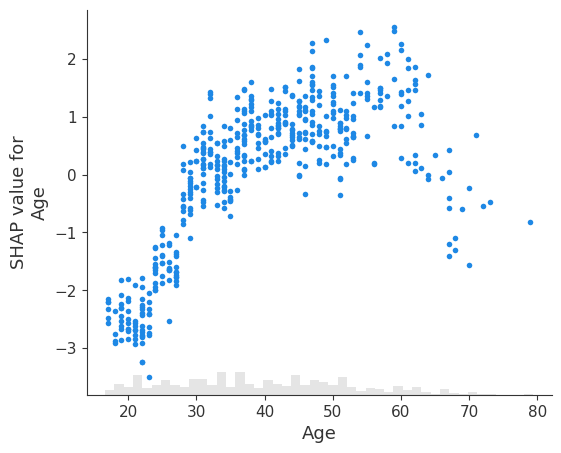

In [2]:
# Slice the "Age" column from the Explanation object
shap.plots.scatter(explanation[:, "Age"])

The vertical spread at a fixed feature value reflects interaction effects or model non-linearity.

## Using color to highlight interaction effects

The vertical spread visible above means that two people of the same age can have very different SHAP values —evidence of feature interactions with other features.

Passing the entire `Explanation` object to `color` lets `shap.plots.scatter` automatically select the feature that best explains the vertical spread.

A distinct vertical color pattern indicates a feature interaction. High values of Education-Num shift SHAP values for Age downward at lower ages, indicating a feature interaction.

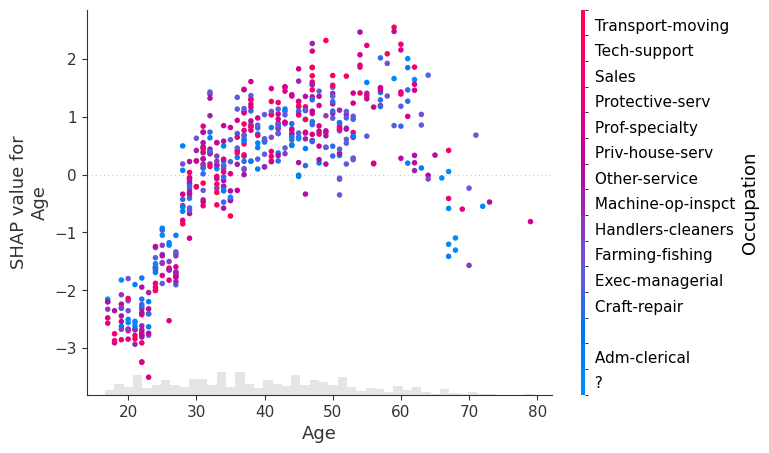

In [3]:
shap.plots.scatter(explanation[:, "Age"], color=explanation)

To inspect a specific interaction partner, pass that feature column explicitly to `color`.

When `explanation.display_data` is set (done in the setup cell), categorical features render with their original string labels on the color bar rather than numeric encodings.

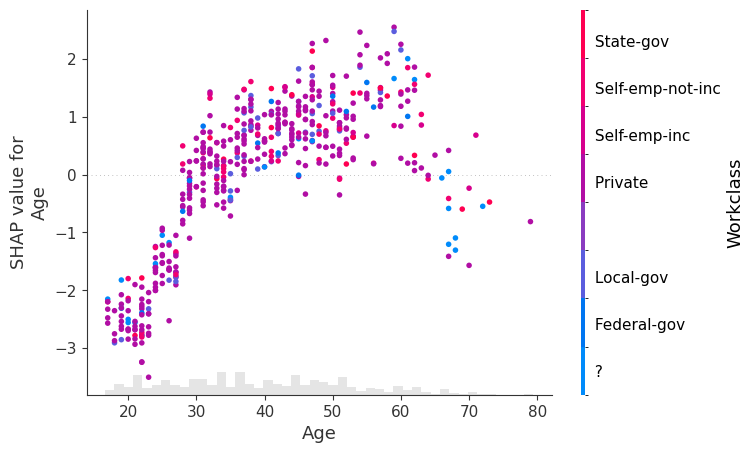

In [4]:
# display_data was set in the setup cell — Workclass now shows original string labels
shap.plots.scatter(explanation[:, "Age"], color=explanation[:, "Workclass"])

## Using global feature-importance orderings

Use `Explanation.abs.mean(0).argsort` to rank features by mean absolute SHAP value, then index into that ranking to select the feature to plot.

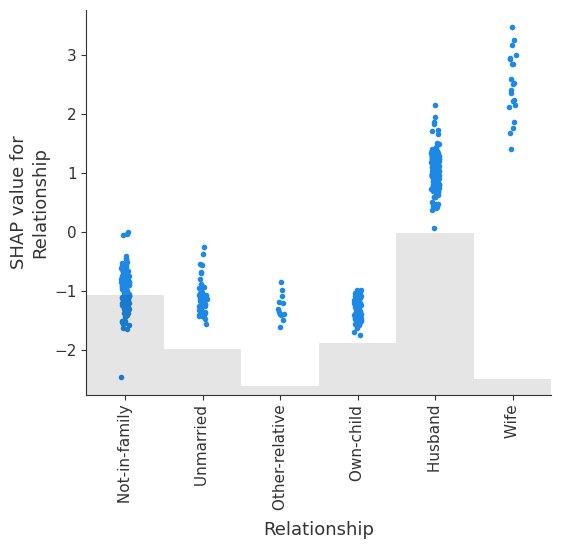

In [5]:
# Most important feature by mean |SHAP|
top_feature = explanation.abs.mean(0).argsort[-1]
shap.plots.scatter(explanation[:, top_feature])

The second most important feature by this metric is `Relationship`:

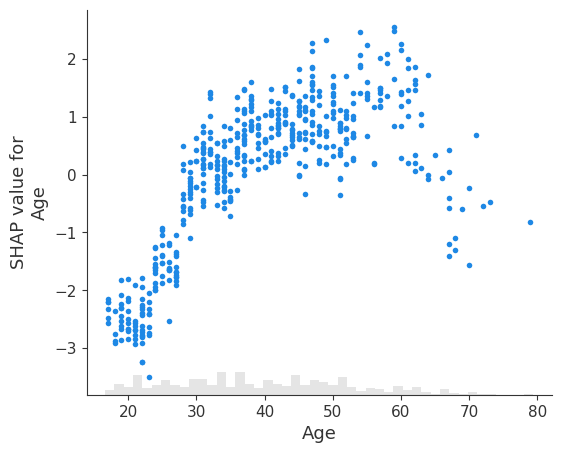

In [6]:
shap.plots.scatter(explanation[:, explanation.abs.mean(0).argsort[-2]])

The ranking is sensitive to the choice of importance measure. Sorting by the *maximum* absolute SHAP value highlights features with large but rare impacts (e.g. Capital Gain).

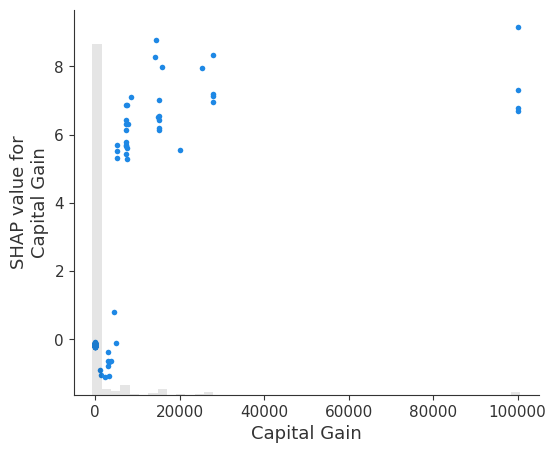

In [7]:
shap.plots.scatter(explanation[:, explanation.abs.max(0).argsort[-1]])

The max is sensitive to outliers. A more robust alternative is to sort by a high percentile of absolute SHAP values:

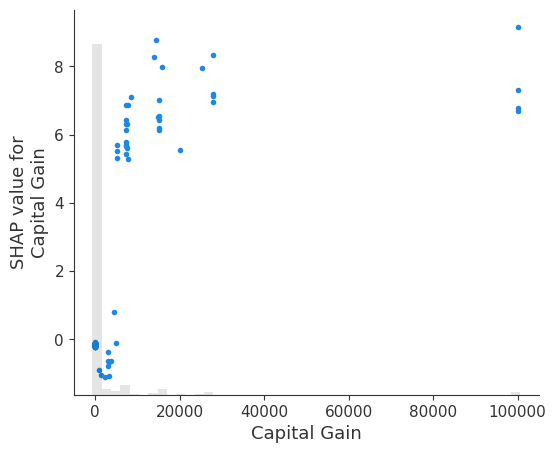

In [8]:
shap.plots.scatter(explanation[:, explanation.abs.percentile(95, 0).argsort[-1]])

## Exploring interaction colorings

`shap.utils.potential_interactions` ranks all other features by interaction strength with the chosen feature. Iterating over the top candidates provides a systematic survey of the most important interaction partners.

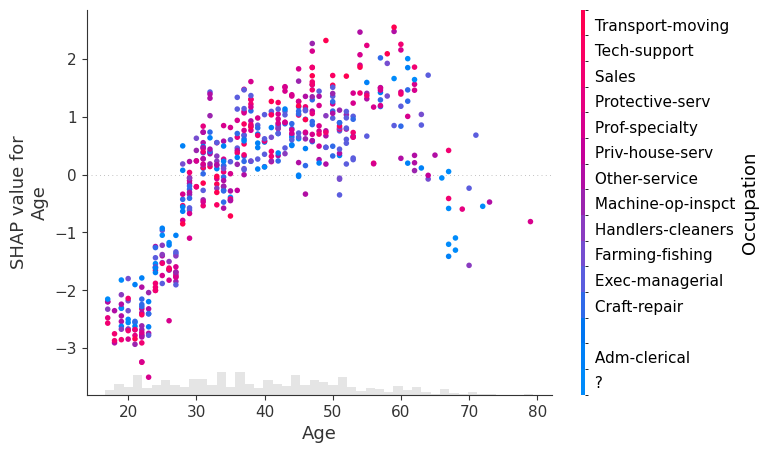

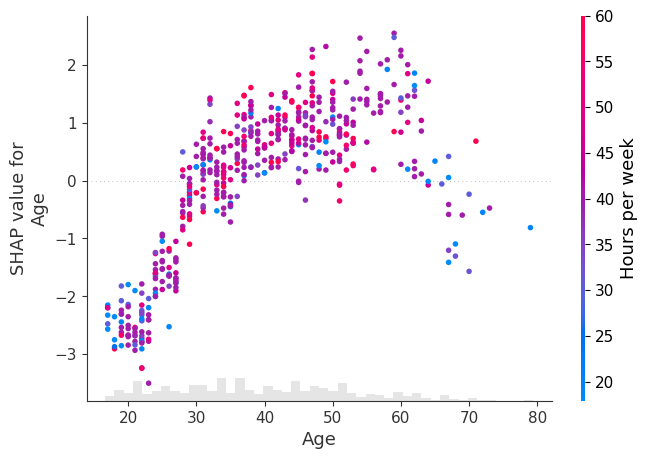

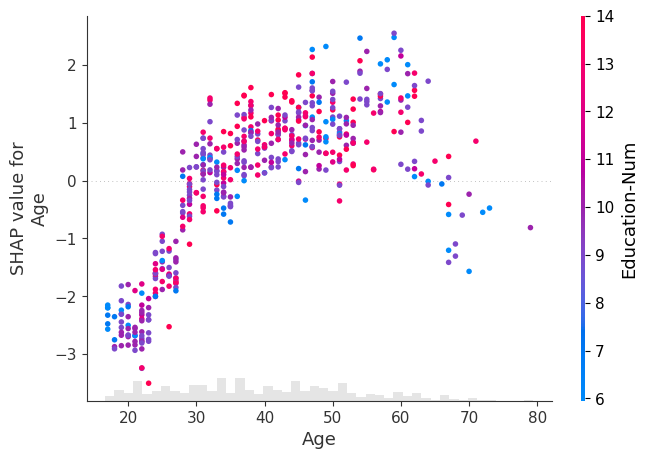

In [9]:
# Rank features by potential interaction strength with Age
inds = shap.utils.potential_interactions(explanation[:, "Age"], explanation)

# Plot Age colored by each of the top candidate interaction features
for i in range(min(3, len(inds))):
    shap.plots.scatter(explanation[:, "Age"], color=explanation[:, inds[i]])

## Customizing figure properties

All examples below use `show=False` or `ax=` to obtain the `Axes` object for post-hoc customization.

### Title and axis labels

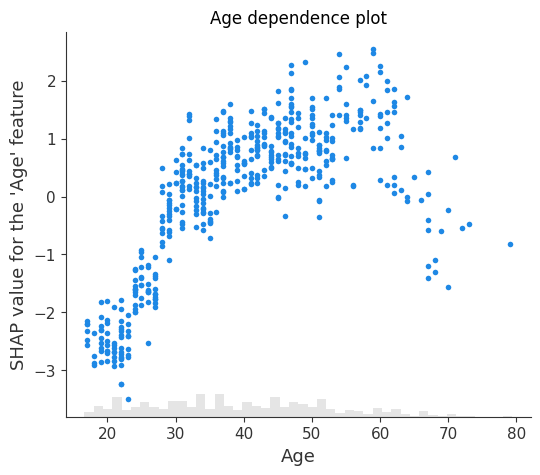

In [10]:
# Pass show=False to retrieve the active Axes for further customization
shap.plots.scatter(explanation[:, "Age"], show=False)
plt.title("Age dependence plot")
plt.ylabel("SHAP value for the 'Age' feature")
# plt.savefig("age_dependence_plot.pdf")  # uncomment to save
plt.show()

### Axis limits

Pass scalar values or `Explanation` objects to `xmin` / `xmax` / `ymin` / `ymax`. When an `Explanation` is passed, `explanation.data` is used for x-axis limits and `explanation.values` for y-axis limits.

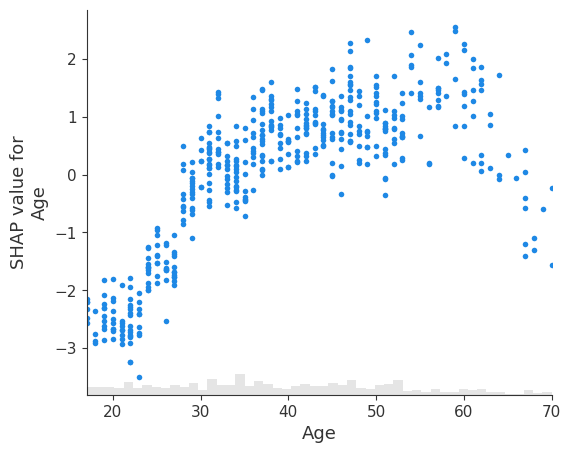

In [11]:
# Clip the x-axis to the 1st–99th percentile of Age feature values
age = explanation[:, "Age"]
shap.plots.scatter(age, xmin=age.percentile(1), xmax=age.percentile(99))

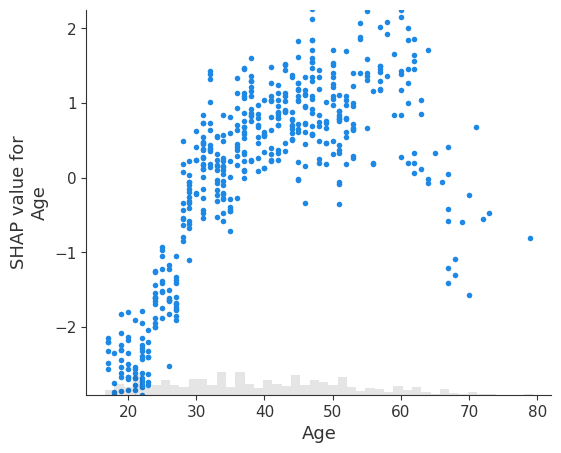

In [12]:
# Clip the y-axis to the 1st–99th percentile of Age SHAP values
age = explanation[:, "Age"]
shap.plots.scatter(age, ymin=age.percentile(1), ymax=age.percentile(99))

### Point opacity

Reducing `alpha` reveals density structure: dense regions become visually saturated while sparse regions remain faint.

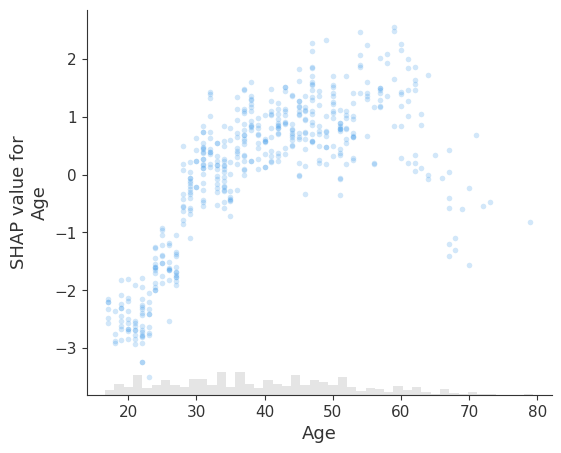

In [13]:
shap.plots.scatter(explanation[:, "Age"], alpha=0.2)

### Point size

The default `dot_size` is 16. Reducing it mitigates overplotting on large samples.

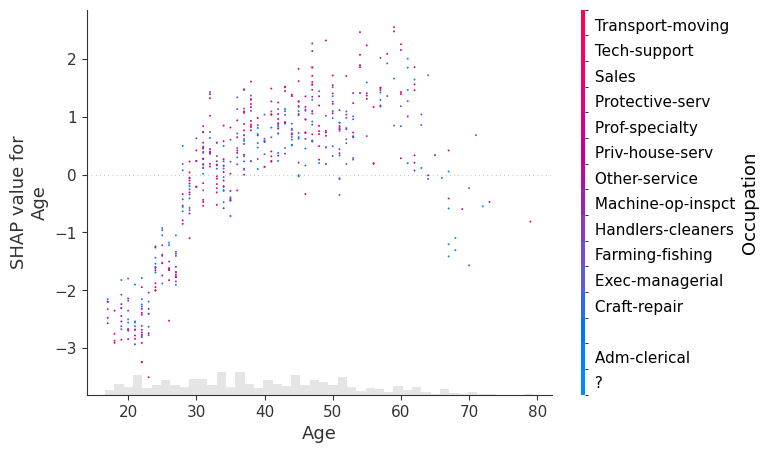

In [14]:
shap.plots.scatter(explanation[:, "Age"], dot_size=2, color=explanation)

### x-jitter

For categorical or heavily-binned features, `x_jitter` spreads overlapping points into readable columns.

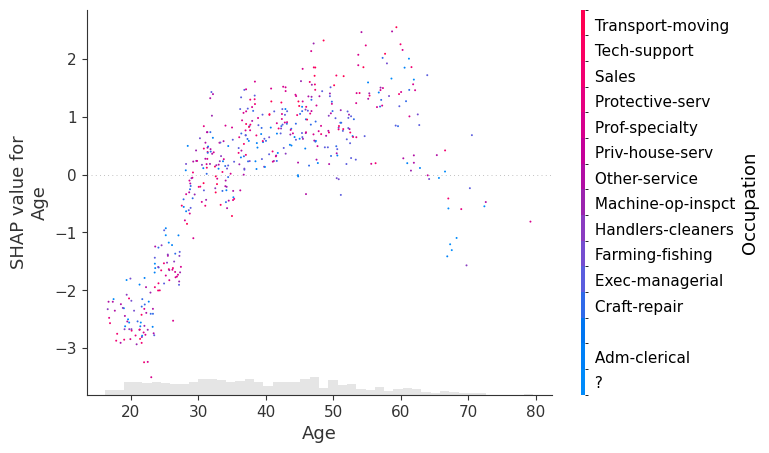

In [15]:
shap.plots.scatter(explanation[:, "Age"], dot_size=2, x_jitter=1, color=explanation)

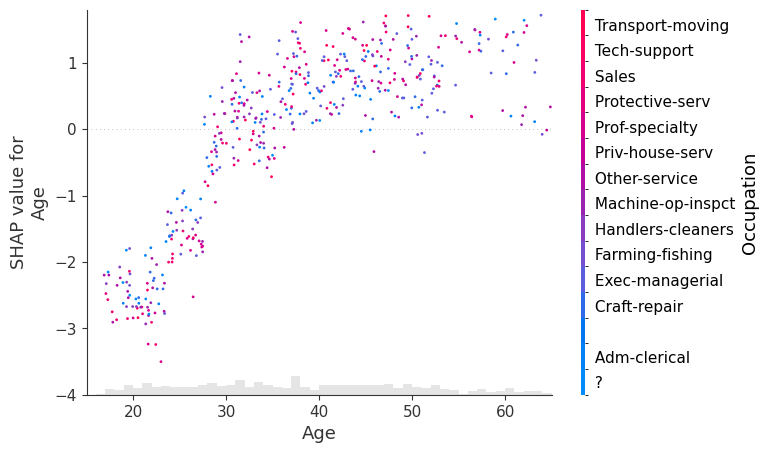

In [16]:
# Combine jitter with explicit axis limits for a tighter, cleaner view
shap.plots.scatter(
    explanation[:, "Age"],
    dot_size=4,
    x_jitter=1,
    color=explanation,
    xmin=15,
    xmax=65,
    ymin=-4,
    ymax=1.8,
)

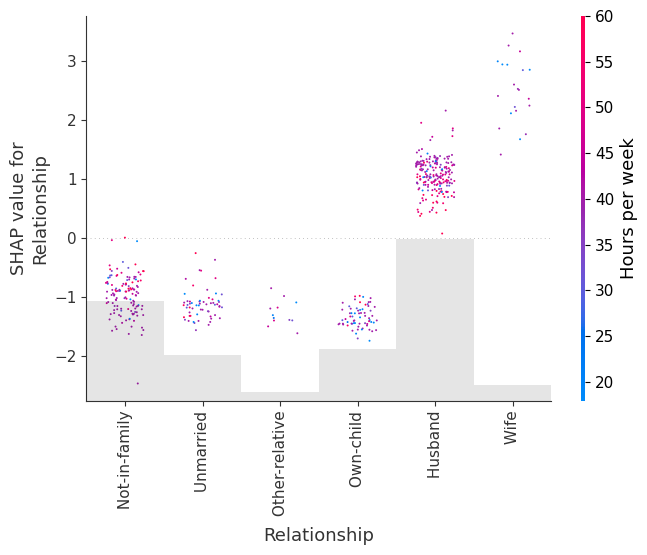

In [17]:
# x-jitter is especially effective for categorical features such as Relationship
shap.plots.scatter(explanation[:, "Relationship"], dot_size=2, x_jitter=0.5, color=explanation)

### Custom colormap

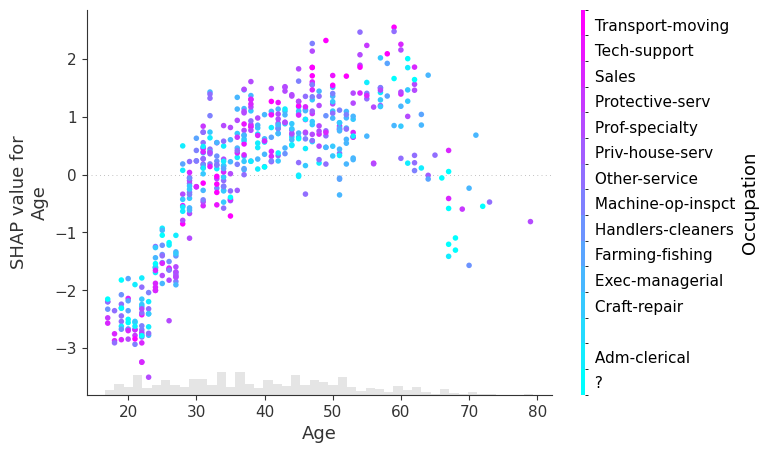

In [18]:
shap.plots.scatter(explanation[:, "Age"], color=explanation, cmap=plt.get_cmap("cool"))

### Full matplotlib control

For maximum flexibility, create a custom `Axes` and pass it via the `ax` parameter, or draw the scatter manually using matplotlib directly.

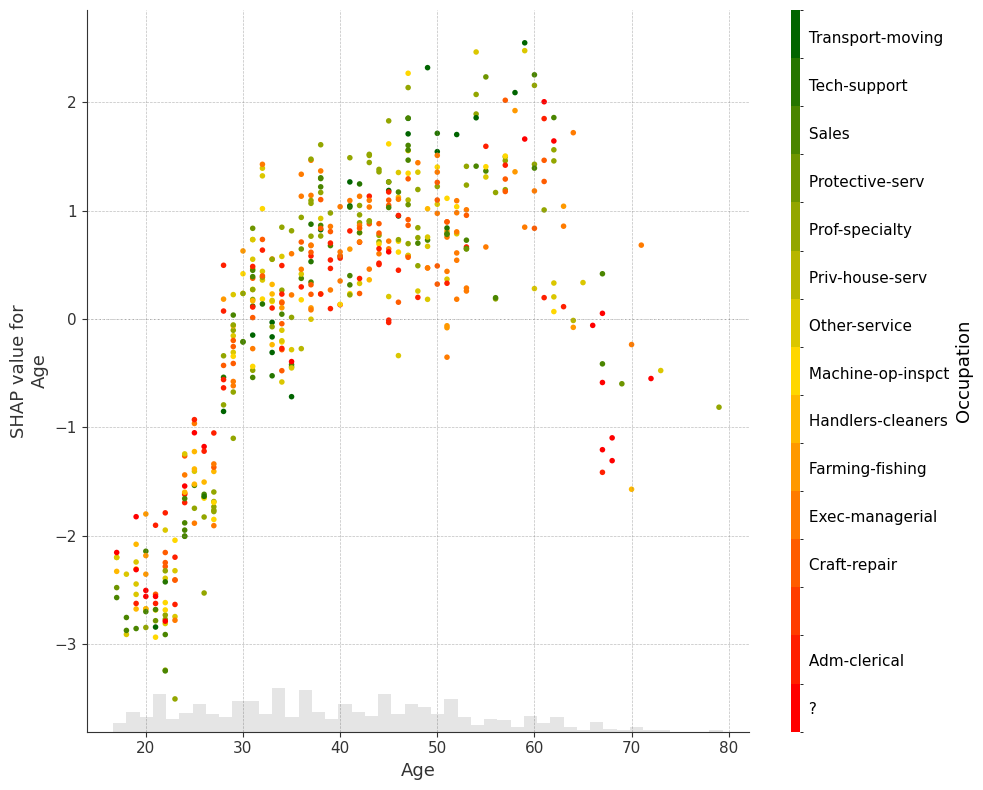

In [19]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(1, 0, 0), (1, 0.843, 0), (0, 0.392, 0)],  # red → gold → dark green
    N=1000,
)

fig, ax = plt.subplots(tight_layout=True, figsize=(10, 8))
ax.grid(linestyle="--", color="gray", linewidth=0.5, zorder=0, alpha=0.5)
shap.plots.scatter(explanation[:, "Age"], color=explanation, cmap=cmap, ax=ax)

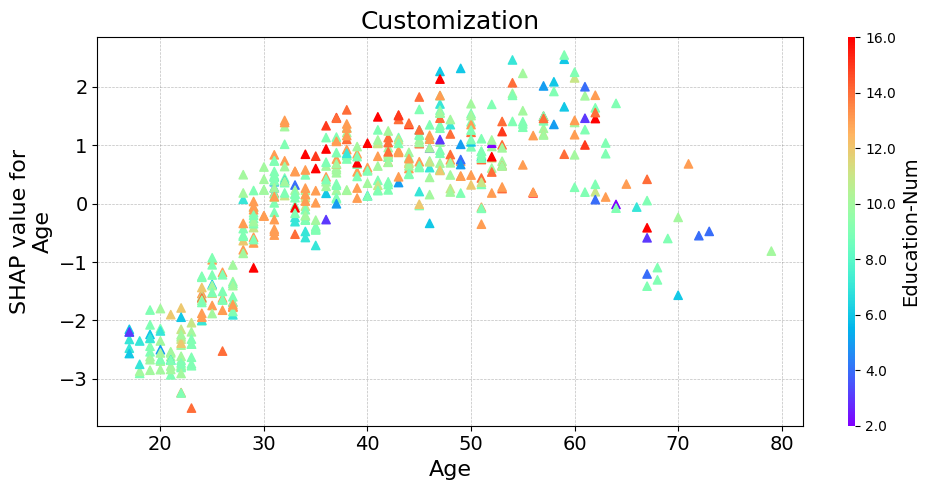

In [20]:
# Direct matplotlib scatter — maximum control over markers, colorbars, and layout
fig, ax = plt.subplots(tight_layout=True, figsize=(10, 5))

sc = ax.scatter(
    explanation[:, "Age"].data,
    explanation[:, "Age"].values,
    c=explanation[:, "Education-Num"].data,
    marker="^",
    cmap=plt.get_cmap("rainbow"),
    rasterized=True,
    zorder=5,
)

cbar = plt.colorbar(sc, aspect=50, format="%2.1f")
cbar.set_label("Education-Num", fontsize=14)
cbar.outline.set_visible(False)

ax.set_title("Customization", fontsize=18)
ax.set_xlabel("Age", fontsize=16)
ax.set_ylabel("SHAP value for\nAge", fontsize=16)
ax.tick_params(labelsize=14)
ax.grid(linestyle="--", color="gray", linewidth=0.5, zorder=0, alpha=0.5)

plt.show()

## Summary

| Plot call | Purpose |
|---|---|
| `shap.plots.scatter(explanation[:, "Feature"])` | Feature dependence |
| `color=explanation` | Auto-detect strongest interaction partner |
| `color=explanation[:, "Feature"]` | Inspect a specific interaction partner |
| `Explanation.abs.mean(0).argsort` | Rank features by mean absolute SHAP |
| `shap.utils.potential_interactions` | Systematically discover interaction partners |

The scatter plot enables:
- Understanding monotone and non-monotone feature effects
- Detecting and visualizing interaction effects
- Exploring model sensitivity across the feature value range

Have an idea for more helpful examples? Pull requests that add to this documentation notebook are encouraged!